# Notebook 1: Data Loading and Exploratory Data Analysis

**Dataset:** Elliptic Bitcoin Dataset

**Objectives:**
- Load all three CSV files (features, classes, edges)
- Inspect shapes and column types
- Analyse class imbalance
- Visualise fraud vs non-fraud distribution
- Check for missing values

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append('../src')

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load Raw Data

In [2]:
features = pd.read_csv('../data/raw/elliptic_txs_features.csv', header=None)
classes  = pd.read_csv('../data/raw/elliptic_txs_classes.csv')
edges    = pd.read_csv('../data/raw/elliptic_txs_edgelist.csv')

print('Features shape :', features.shape)
print('Classes  shape :', classes.shape)
print('Edges    shape :', edges.shape)

Features shape : (203769, 167)
Classes  shape : (203769, 2)
Edges    shape : (234355, 2)


## 2. Inspect Data

In [3]:
features.head(3)

,0,1,2,3,4,5,6,7,8,9,...,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162097,...,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162112,...,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.12197,-0.043875,-0.113002,-0.061584,-0.162749,...,0.670883,0.439728,-0.979074,-0.978556,-0.098889,-0.106715,-0.131155,-0.183671,-0.120613,-0.119792


In [4]:
classes.head()

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


In [5]:
edges.head()

,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


## 3. Class Distribution

class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64


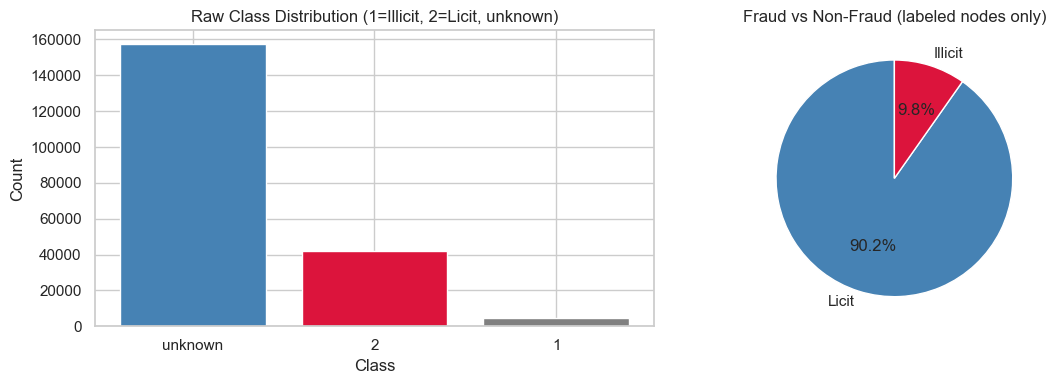

Fraud ratio: 9.8%


In [6]:
class_counts = classes['class'].value_counts()
print(class_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(class_counts.index.astype(str), class_counts.values,
            color=['steelblue', 'crimson', 'grey'])
axes[0].set_title('Raw Class Distribution (1=Illicit, 2=Licit, unknown)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

known = classes[classes['class'] != 'unknown'].copy()
known['label'] = known['class'].map({'1':1,'2':0,1:1,2:0})
label_counts = known['label'].value_counts().sort_index()

axes[1].pie(label_counts.values,
            labels=['Licit','Illicit'],
            autopct='%1.1f%%',
            colors=['steelblue','crimson'],
            startangle=90)
axes[1].set_title('Fraud vs Non-Fraud (labeled nodes only)')

plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=150)
plt.show()
print(f'Fraud ratio: {label_counts[1]/label_counts.sum()*100:.1f}%')

## 4. Missing Values

In [7]:
print('Missing in features:', features.isnull().sum().sum())
print('Missing in classes :', classes.isnull().sum().sum())
print('Missing in edges   :', edges.isnull().sum().sum())

Missing in features: 0
Missing in classes : 0
Missing in edges   : 0


## 5. Feature Statistics

In [8]:
feature_data = features.iloc[:, 2:]  # skip node ID and time step
print('Feature value ranges:')
print(feature_data.describe().T[['min','max','mean','std']].head(15))

Feature value ranges:


         min         max          mean       std
2  -0.172983   71.681966  2.454849e-17  1.000002
3  -0.210553   73.595052 -7.531922e-18  1.000002
4  -1.756361    2.683580  2.231681e-17  1.000002
5  -0.121970   49.027598  6.241732e-17  1.000002
6  -0.063725  260.090707  7.653968e-17  1.000002
7  -0.113002   54.565178  5.858162e-17  1.000002
8  -0.061584  113.440873  3.068561e-17  1.000002
9  -0.163646   73.354565  3.570689e-17  1.000002
10 -0.169460   72.318396  4.630738e-17  1.000002
11 -0.049707  189.186944  5.125892e-17  1.000002
12 -0.165949   73.270217  1.227424e-17  1.000002
13 -2.516705    2.459222  5.453670e-17  1.000002
14 -2.486106    2.415325 -1.604021e-17  1.000002
15 -0.063200  265.263236  4.913185e-17  1.000002
16 -0.013282  119.477578  9.066203e-17  1.000002


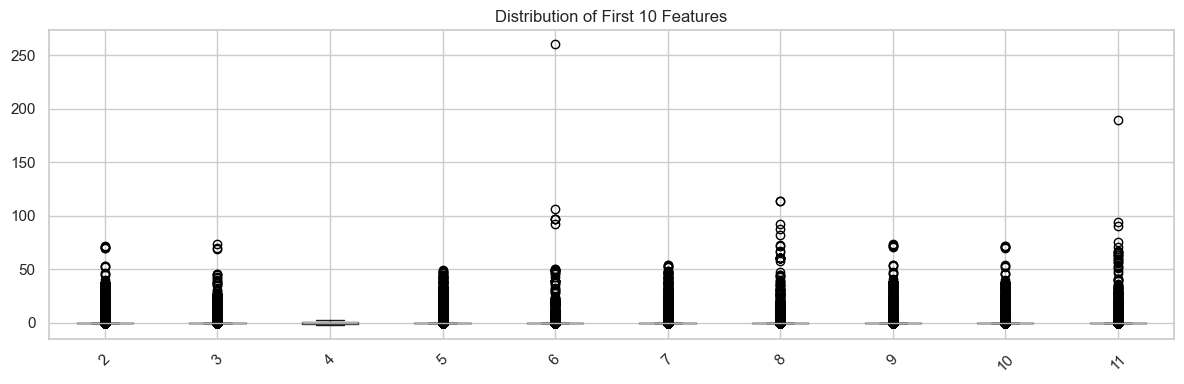

In [9]:
plt.figure(figsize=(12, 4))
feature_data.iloc[:, :10].boxplot()
plt.title('Distribution of First 10 Features')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../results/figures/feature_boxplots.png', dpi=150)
plt.show()

## 6. Time Step Analysis

Time steps: 1 to 49


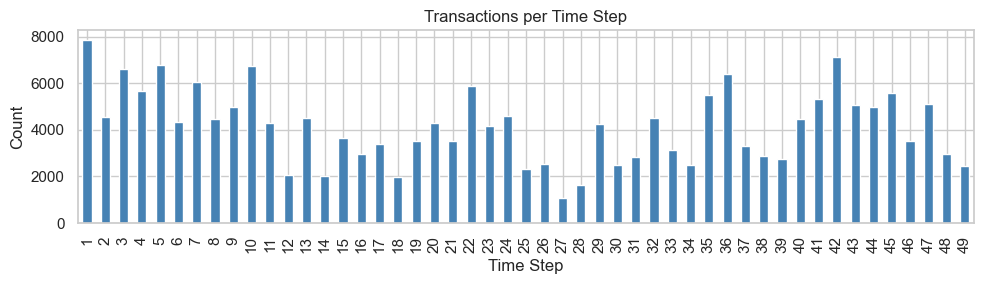

In [10]:
# Column 1 is the time step in the Elliptic dataset
time_steps = features.iloc[:, 1]
print(f'Time steps: {time_steps.min()} to {time_steps.max()}')

plt.figure(figsize=(10, 3))
time_steps.value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Transactions per Time Step')
plt.xlabel('Time Step')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../results/figures/time_steps.png', dpi=150)
plt.show()

## 7. Graph Statistics

In [11]:
print(f'Total nodes (transactions): {features.shape[0]:,}')
print(f'Total edges               : {edges.shape[0]:,}')
print(f'Labeled nodes             : {known.shape[0]:,}')
print(f'Average degree            : {edges.shape[0]*2 / features.shape[0]:.2f}')

Total nodes (transactions): 203,769
Total edges               : 234,355
Labeled nodes             : 46,564
Average degree            : 2.30
